In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.gaussian_process import GaussianProcessRegressor as gpr
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
dataset = pd.read_csv("D:/Airfoil_Surrogate_Modelling/Dataset.csv")

X = dataset.drop(['CL', 'CD', 'Airfoil'], axis=1)
y_cl = dataset['CL']
y_cd = dataset['CD']

# Create the groups (airfoil names)
groups = dataset['Airfoil']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# This splits by AIRFOIL, not by rows!
train_idx, test_idx = next(gss.split(X, y_cl, groups=groups))

# Now use these indices to split your data
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_cl_train = y_cl.iloc[train_idx]
y_cl_test = y_cl.iloc[test_idx]
y_cd_train = y_cd.iloc[train_idx]
y_cd_test = y_cd.iloc[test_idx]

# Verify no airfoil appears in both sets
train_airfoils = set(dataset.iloc[train_idx]['Airfoil'])
test_airfoils = set(dataset.iloc[test_idx]['Airfoil'])
overlap = train_airfoils.intersection(test_airfoils)
print(f"Overlapping airfoils: {overlap}")  # Should be empty!
print(f"Train airfoils: {len(train_airfoils)}")
print(f"Test airfoils: {len(test_airfoils)}")

Overlapping airfoils: set()
Train airfoils: 260
Test airfoils: 65


## Scaling

In [4]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_cl = StandardScaler()
y_cl_train_scaled = scaler_cl.fit_transform(y_cl_train.values.reshape(-1, 1)).ravel()

y_cd_train_log = np.log(y_cd_train.values.reshape(-1, 1))
scaler_cd = StandardScaler()
y_cd_train_scaled = scaler_cd.fit_transform(y_cd_train_log).ravel()

## Define Kernels

In [5]:
# Define Cl kernel: Constant * RBF + White Noise
kernel_cl = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2))

# Define Cd kernel: Constant * Matern + White Noise
kernel_cd = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2))

In [6]:
# Note: GPR scales at O(n^3). Training on 2000 rows might take 1 to 5 minutes!
# We set normalize_y=False because we manually scaled the targets perfectly above.

gpr_cl = gpr(kernel=kernel_cl, normalize_y=False, alpha = 0.0, n_restarts_optimizer=10, random_state=42)
gpr_cd = gpr(kernel=kernel_cd, normalize_y=False, alpha = 0.0, n_restarts_optimizer=10, random_state=42)

gpr_cl.fit(X_train_scaled, y_cl_train_scaled)
print(f"Optimized CL Kernel: {gpr_cl.kernel_}")
gpr_cd.fit(X_train_scaled, y_cd_train_scaled)
print(f"Optimized CD Kernel: {gpr_cd.kernel_}")

Optimized CL Kernel: 0.77**2 * RBF(length_scale=3.33) + WhiteKernel(noise_level=0.00229)
Optimized CD Kernel: 1.08**2 * Matern(length_scale=2.67, nu=2.5) + WhiteKernel(noise_level=0.00648)


In [8]:
# GPR gives you two things: The prediction (mean) and the uncertainty (std_deviation)
pred_cl_scaled, std_cl_scaled = gpr_cl.predict(X_test_scaled, return_std=True)
pred_cd_scaled, std_cd_scaled = gpr_cd.predict(X_test_scaled, return_std=True)

# We reshape to 2D for the scaler, then flatten it back to 1D using .ravel()
y_cl_pred = scaler_cl.inverse_transform(pred_cl_scaled.reshape(-1, 1)).ravel()

# First undo the scaling to get back to the log domain: ln(CD)
pred_cd_log = scaler_cd.inverse_transform(pred_cd_scaled.reshape(-1, 1)).ravel()
# Then apply exp() to completely reverse the natural log transformation
y_cd_pred = np.exp(pred_cd_log)

r2_cl = r2_score(y_cl_test, y_cl_pred)
rmse_cl = np.sqrt(mean_squared_error(y_cl_test, y_cl_pred))

r2_cd = r2_score(y_cd_test, y_cd_pred)
rmse_cd = np.sqrt(mean_squared_error(y_cd_test, y_cd_pred))

print("=== FINAL GPR SURROGATE PERFORMANCE (PHYSICAL SCALE) ===")
print(f"Lift Coefficient (CL) - R² Score: {r2_cl:.4f} | RMSE: {rmse_cl:.6f}")
print(f"Drag Coefficient (CD) - R² Score: {r2_cd:.4f} | RMSE: {rmse_cd:.6f}\n")

=== FINAL GPR SURROGATE PERFORMANCE (PHYSICAL SCALE) ===
Lift Coefficient (CL) - R² Score: 0.9980 | RMSE: 0.018859
Drag Coefficient (CD) - R² Score: 0.9937 | RMSE: 0.000327



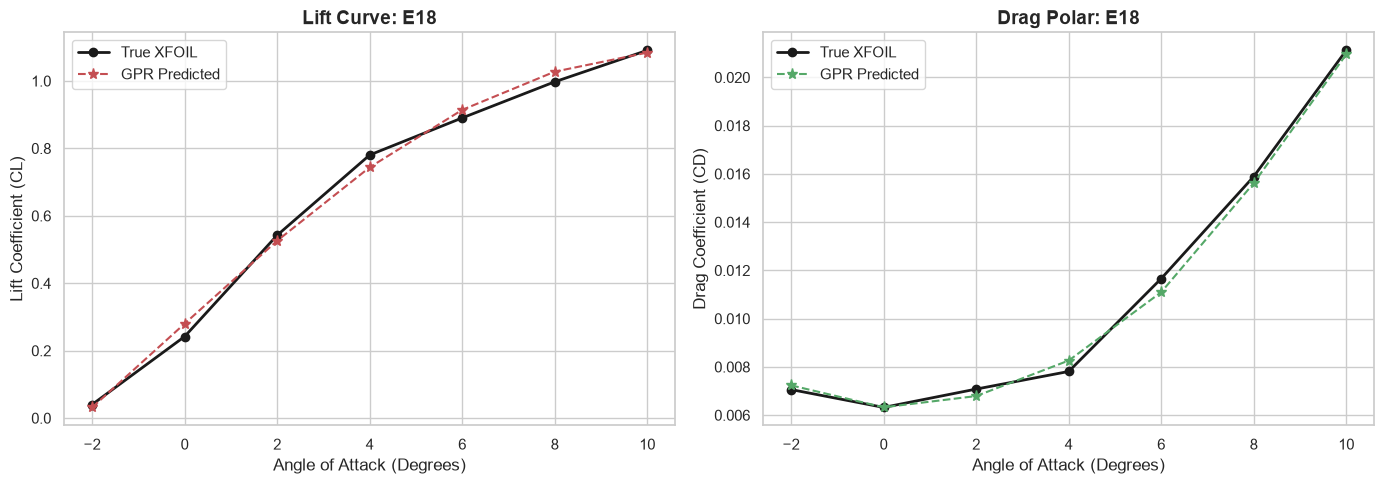

In [11]:
import seaborn as sns
# 1. Rebuild a Results DataFrame for easy plotting
# We use test_idx to grab the correct Airfoil names that were dropped from X_test
results_df = X_test.copy()
results_df['Airfoil'] = dataset.iloc[test_idx]['Airfoil']
results_df['CL_Actual'] = y_cl_test
results_df['CL_Predicted'] = y_cl_pred
results_df['CD_Actual'] = y_cd_test
results_df['CD_Predicted'] = y_cd_pred

# 2. Pick a random unique airfoil from the test set to visualize
sample_airfoil = results_df['Airfoil'].unique()[42]

# Filter the data for only this airfoil and sort it by Alpha so the line draws correctly
plot_data = results_df[results_df['Airfoil'] == sample_airfoil].sort_values(by='Alpha')

# 3. Create the plots (Side-by-side Lift and Drag)
sns.set_theme(style="whitegrid") # Makes the plots look modern and clean
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- LIFT CURVE (CL vs Alpha) ---
# Plot True values as a thick black solid line
ax1.plot(plot_data['Alpha'], plot_data['CL_Actual'], 'ko-', label='True XFOIL', linewidth=2)
# Plot ML Predicted values as red dashed lines with star markers
ax1.plot(plot_data['Alpha'], plot_data['CL_Predicted'], 'r*--', label='GPR Predicted', markersize=8)

ax1.set_xlabel('Angle of Attack (Degrees)', fontsize=12)
ax1.set_ylabel('Lift Coefficient (CL)', fontsize=12)
ax1.set_title(f'Lift Curve: {sample_airfoil}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# --- DRAG CURVE (CD vs Alpha) ---
# Plot True values as a thick black solid line
ax2.plot(plot_data['Alpha'], plot_data['CD_Actual'], 'ko-', label='True XFOIL', linewidth=2)
# Plot ML Predicted values as green dashed lines with star markers
ax2.plot(plot_data['Alpha'], plot_data['CD_Predicted'], 'g*--', label='GPR Predicted', markersize=8)

ax2.set_xlabel('Angle of Attack (Degrees)', fontsize=12)
ax2.set_ylabel('Drag Coefficient (CD)', fontsize=12)
ax2.set_title(f'Drag Polar: {sample_airfoil}', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
import joblib
joblib.dump(gpr_cl, 'gpr_cl.pkl')
joblib.dump(gpr_cd, 'gpr_cd.pkl')

joblib.dump(scaler_X, 'scaler_X.pkl')       # For inputs
joblib.dump(scaler_cl, 'scaler_cl.pkl')     # For CL outputs
joblib.dump(scaler_cd, 'scaler_cd.pkl')     # For CD outputs

['scaler_cd.pkl']